<a href="https://colab.research.google.com/github/ethanboyjeff/ELE2038-Coursework/blob/main/ELE2038_CW_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Equilibrium: x = 0.44 m, i = 0.4742 A, V = 1043.20 V


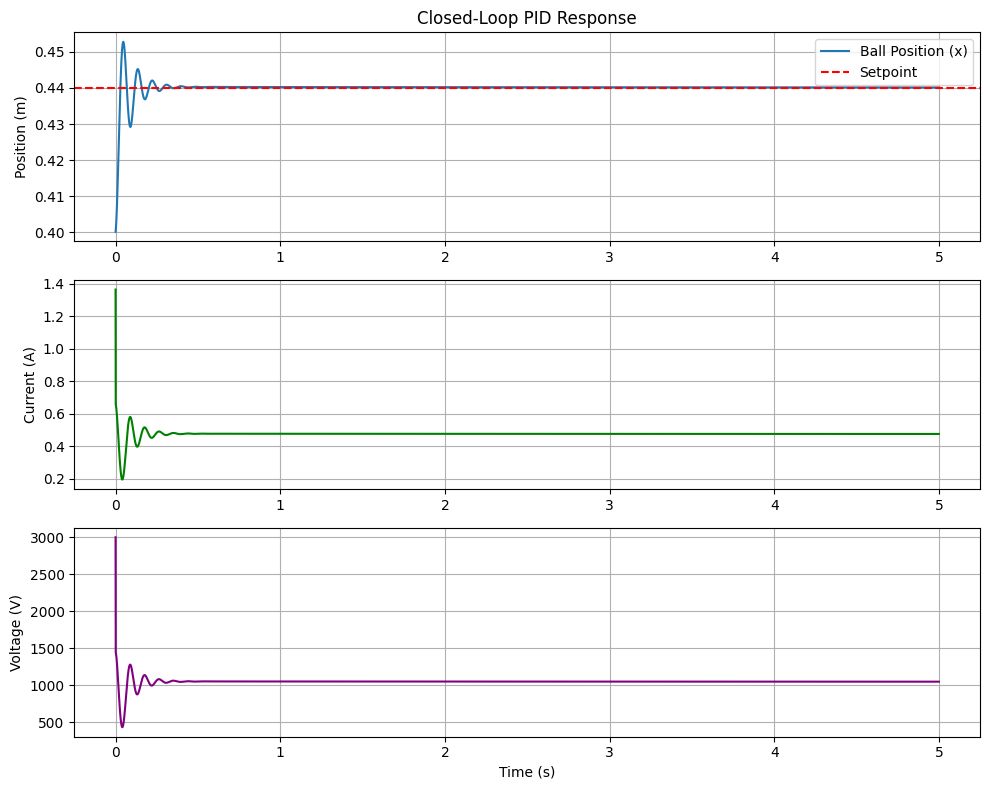

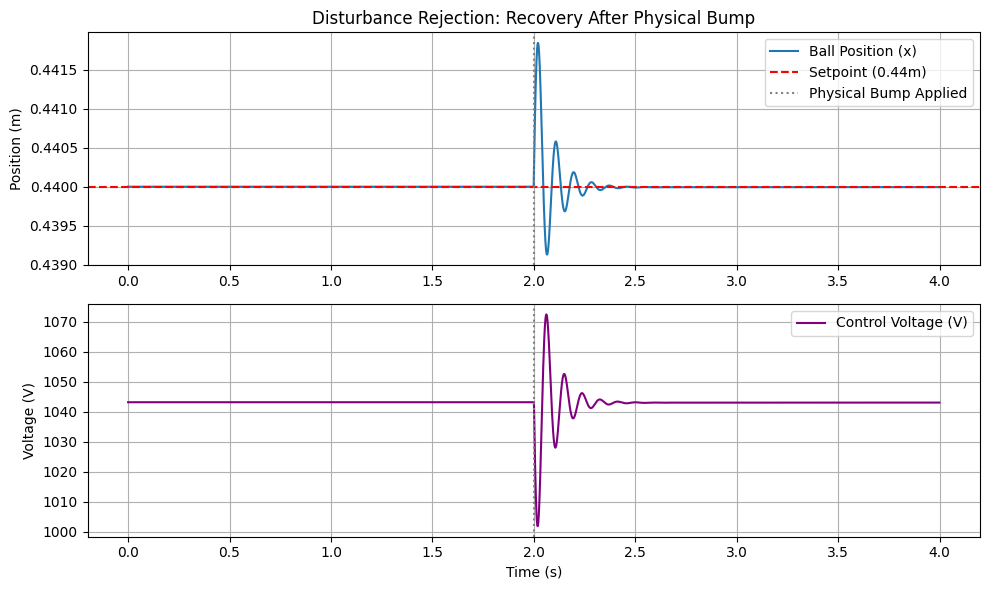

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import StateSpace, lsim, TransferFunction

# 1. System Parameters
m = 0.462
g = 9.81
r = 0.123
k = 1885.0
b = 10.4
d = 0.42
delta = 0.65
phi = np.deg2rad(41) # 41 degrees
R = 2200.0
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811       # Magnetic constant
tau_m = 0.03    # Sensor time constant
Km = 1.0        # Sensor (DC) gain

# Derived effective mass for a rolling sphere
m_eff = (7/5) * m

# 2. Operating Point / Equilibrium
x_sp = 0.44     # Setpoint position (m)
# Mechanical equilibrium to find i_eq
# F_mag = mg*sin(phi) + k(x - d)
f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
V_eq = R * i_eq # Voltage at equilibrium

print(f"Equilibrium: x = {x_sp} m, i = {i_eq:.4f} A, V = {V_eq:.2f} V")

# 3. Nonlinear System ODEs
def system_dynamics(t, state, V_input):
    # 4 state variables
    x, v, i, x_m = state

    # Distance to electromagnet
    y = delta - x

    # Mechanical ODE: m_eff*x_ddot = F_grav - k(x-d) - b*v + F_mag
    f_mag = c * i**2 / y**2
    x_dot = v
    # Force balance equation rearranged to solve for acceleration
    v_dot = (m*g*np.sin(phi) - k*(x - d) - b*v + f_mag) / m_eff

    # Electrical ODE: V = R*i + L(x)*i_dot + i*(dL/dx)*v
    Lx = L0 + L1 * np.exp(-alpha * y)
    dLdx = L1 * alpha * np.exp(-alpha * y)
    i_dot = (V_input - R*i - i * dLdx * v) / Lx

    # Sensor: Solves for the rate of change of the measured position
    x_m_dot = (Km * x - x_m) / tau_m

    return [x_dot, v_dot, i_dot, x_m_dot]

# 4. PID Controller Implementation
# Based on design requirements: OS < 10%, Settling < 2s
Kp = 10000.0
Ki = 5000
Kd = 850.0

# By implementing a time-step loop, we can actively compute a new control
# voltage (V_control) at every millisecond using this pid_control function
def pid_control(t, state, integral_error, last_error):
    x = state[3]
    error = x_sp - x
    dt = 0.001 # Approximation for derivative

    prop = Kp * error
    integ = Ki * (integral_error + error * dt)
    deriv = Kd * (error - last_error) / dt

    V_control = V_eq + prop + integ + deriv
    return np.clip(V_control, 0, 3000), error # Clip to realistic voltage

# 5. Revised Simulation Loop with PID
dt = 0.001
t_final = 5
time_steps = np.arange(0, t_final, dt)

# Initialize tracking variables
integral_error = 0
last_error = 0
current_state = [0.40, 0, i_eq, 0.40]
              # [actual_x, velocity, current, measured_x]

# Storage for plotting
history_t = []
history_x = []
history_i = []
history_v = []

for t in time_steps:
    # 1. Calculate PID control voltage
    v_out, error = pid_control(t, current_state, integral_error, last_error)

    # 2. Update error terms for next iteration
    integral_error += error * dt
    last_error = error

    # 3. Simulate the physics for a tiny step (dt) using the PID voltage
    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(v_out,))

    # 4. Save results and update current state
    current_state = sol.y[:, -1]
    history_t.append(t)
    history_x.append(current_state[0])
    history_i.append(current_state[2])
    history_v.append(v_out)

# Convert to arrays for plotting
history_t = np.array(history_t)
history_x = np.array(history_x)

# 6. Plotting Results
plt.figure(figsize=(10, 8))

# Position Plot
plt.subplot(3, 1, 1)
plt.plot(history_t, history_x, label='Ball Position (x)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint')
plt.ylabel('Position (m)')
plt.title('Closed-Loop PID Response')
plt.legend(); plt.grid(True)

# Current Plot
plt.subplot(3, 1, 2)
plt.plot(history_t, history_i, color='green', label='Current (i)')
plt.ylabel('Current (A)')
plt.grid(True)

# Control Voltage Plot (Important to check for saturation)
plt.subplot(3, 1, 3)
plt.plot(history_t, history_v, color='purple', label='Control Voltage (V)')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.grid(True)

plt.tight_layout()
plt.show()


# 7. Disturbance Rejection Test
# Run for 4 seconds.
t_final_dist = 4.0
time_steps_dist = np.arange(0, t_final_dist, dt)

# Start already settled AT the setpoint (0.44m) and at equilibrium current
current_state = [x_sp, 0, i_eq, x_sp]
integral_error = 0
last_error = 0

history_t_dist = []
history_x_dist = []
history_v_dist = []

for t in time_steps_dist:
    # INJECT DISTURBANCE: At exactly t = 2.0s, give the ball a sudden physical bump
    # This instantly changes its velocity by 0.15 m/s down the ramp
    if abs(t - 2.0) < dt/2:
        current_state[1] += 0.15

    # 1. Calculate PID control voltage
    v_out, error = pid_control(t, current_state, integral_error, last_error)

    # 2. Update error terms
    integral_error += error * dt
    last_error = error

    # 3. Simulate one step
    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(v_out,))

    # 4. Save results
    current_state = sol.y[:, -1]
    history_t_dist.append(t)
    history_x_dist.append(current_state[0])
    history_v_dist.append(v_out)

# Plotting the Disturbance Rejection
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(history_t_dist, history_x_dist, label='Ball Position (x)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint (0.44m)')
plt.axvline(x=2.0, color='grey', linestyle=':', label='Physical Bump Applied')
plt.ylabel('Position (m)')
plt.title('Disturbance Rejection: Recovery After Physical Bump')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(history_t_dist, history_v_dist, color='purple', label='Control Voltage (V)')
plt.axvline(x=2.0, color='grey', linestyle=':')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
